# Quadrupole-octopole alignment, $S_\mathrm{QO}$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import polymv
import pylab as pl
import math
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Parameters
lmax                    = 3
Nside_in                = 128
save_stats              = True
load_stats_from_cluster = True

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

In [3]:
# Directories
sims_dir  = "../../data/sims/"
stats_dir = "../../data/stats/"
real_dir  = "../../data/real/"
masks_dir = "../../data/masks/"

# Planck maps
#names_Planck  = ["commander_nside_128", "nilc_nside_128", "sevem_nside_128", "smica_nside_128", "cleaned_70GHz_v9_nside_128",     "cleaned_94GHz_v9_nside_128", "cleaned_100GHz_v9_nside_128", "cleaned_143GHz_v9_nside_128"]
names_Planck  = ["cleaned_70GHz_v9_nside_128",     "cleaned_94GHz_v9_nside_128", "cleaned_100GHz_v9_nside_128", "cleaned_143GHz_v9_nside_128",   "commander_nside_128",   "nilc_nside_128",   "sevem_nside_128",   "smica_nside_128"]
labels_Planck = [      r"$70\, \mathrm{GHz}$",           r"$94\, \mathrm{GHz}$",       r"$100\, \mathrm{GHz}$",       r"$143\, \mathrm{GHz}$", r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$"]
colors_Planck = ["tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [      "-",    "-",     "-",     "-",      "--",      "--",     "--",    "--"]
Nmaps = len(names_Planck)
index_Planck  = 4
index_Hayley  = 2

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
mask_files = ["1percent_mask_v9.fits", "com_mask_cutoff_0.9_nside_128.fits"]
Nmasks = len(names_mask)

# Multipoles l = 2,3,4,5
markers       = [".", ".", "s", "d", "x", "."]

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':16})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  16}

In [5]:
# Load masks
masks = CMBanom.read_masks(masks_dir, mask_files, Nside_in)

In [6]:
# Read in maps in muK
maps_Planck = [hp.read_map(real_dir+f"map_{names_Planck[n]}.fits") for n in range(Nmaps)]

In [7]:
# Compute alms
alms_Planck = [[hp.sphtfunc.map2alm(maps_Planck[n]*masks[m], lmax=lmax) for n in range(Nmaps)] for m in range(Nmasks)]

In [8]:
# Compute multipole vectors Planck
mvs_Planck = [[],[],[]]
for m in range(Nmasks):
    for n in range(Nmaps):
        mvs_all_Planck = [polymv.mvs.m_vectors(alms_Planck[m][n], ell) for ell in range(lmax+1)]
        mvs_Planck[m].append([polymv.otherfuncs.mvs_north(mvs_all_Planck[ell]) for ell in range(lmax+1)])

In [9]:
# Print multipole vectors of \ell=2 and 3 to compare to Schwarz++ 2004

for m in range(Nmasks): 
    print("--------------")
    print(names_mask[m])
    for n in range(Nmaps):
        print("-- "+names_Planck[n]+" --")
        mvs_vec = [hp.ang2vec(theta=mvs_Planck[m][n][ell].T[0], phi=mvs_Planck[m][n][ell].T[1]) for ell in range(lmax+1)]
        mvs_lonlat= [hp.vec2ang(mvs_vec[ell], lonlat=True) for ell in range(lmax+1)]
        ell=2
        print("ell=2")
        for i in range(ell):
            print("v"+str(i)+" = (%(lon).2f, %(lat).2f)"%{"lon":mvs_lonlat[ell][0][i],"lat":mvs_lonlat[ell][1][i]})
        ell=3
        print("ell=3")
        for i in range(ell):
            print("v"+str(i)+" = (%(lon).2f, %(lat).2f)"%{"lon":mvs_lonlat[ell][0][i],"lat":mvs_lonlat[ell][1][i]})
        print(" ")

--------------
fullsky
-- cleaned_70GHz_v9_nside_128 --
ell=2
v0 = (0.33, 24.10)
v1 = (108.64, 19.43)
ell=3
v0 = (318.62, 4.67)
v1 = (26.21, 8.54)
v2 = (80.71, 36.99)
 
-- cleaned_94GHz_v9_nside_128 --
ell=2
v0 = (1.36, 24.54)
v1 = (104.58, 18.73)
ell=3
v0 = (318.72, 4.26)
v1 = (25.92, 9.17)
v2 = (78.07, 35.41)
 
-- cleaned_100GHz_v9_nside_128 --
ell=2
v0 = (3.27, 23.49)
v1 = (107.02, 19.20)
ell=3
v0 = (317.95, 4.91)
v1 = (25.80, 8.97)
v2 = (80.26, 36.31)
 
-- cleaned_143GHz_v9_nside_128 --
ell=2
v0 = (5.53, 22.93)
v1 = (105.24, 18.32)
ell=3
v0 = (317.49, 5.46)
v1 = (25.71, 9.21)
v2 = (78.94, 36.11)
 
-- commander_nside_128 --
ell=2
v0 = (3.03, 27.92)
v1 = (122.80, 23.25)
ell=3
v0 = (315.11, 6.62)
v1 = (24.49, 7.84)
v2 = (85.23, 37.73)
 
-- nilc_nside_128 --
ell=2
v0 = (15.76, 23.55)
v1 = (115.24, 19.78)
ell=3
v0 = (315.58, 7.78)
v1 = (23.28, 9.27)
v2 = (86.68, 37.12)
 
-- sevem_nside_128 --
ell=2
v0 = (14.76, 25.89)
v1 = (91.49, 12.13)
ell=3
v0 = (319.56, 0.81)
v1 = (31.53, 6.65)
v2 =

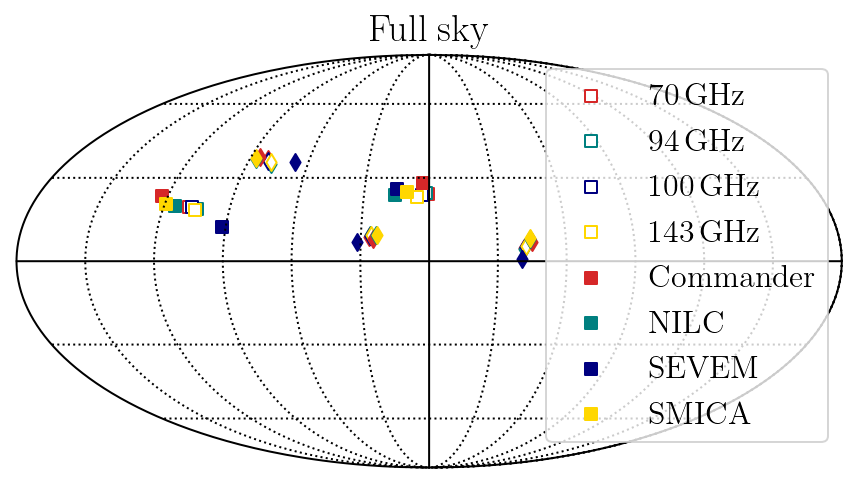

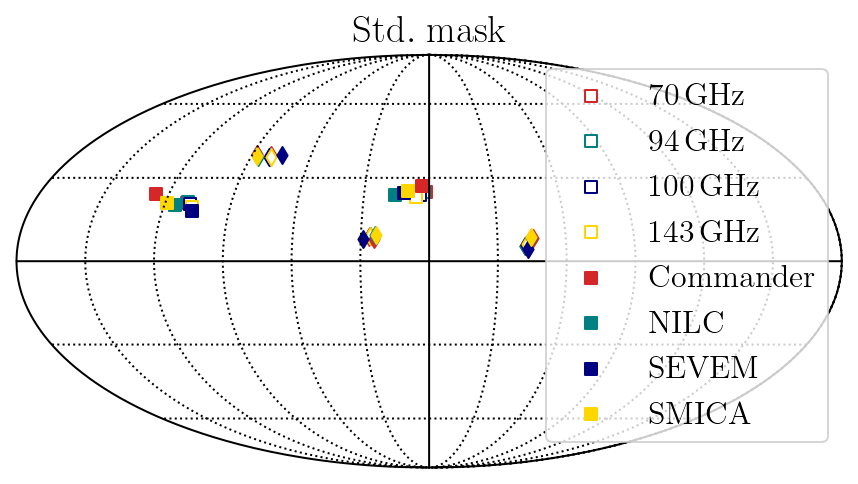

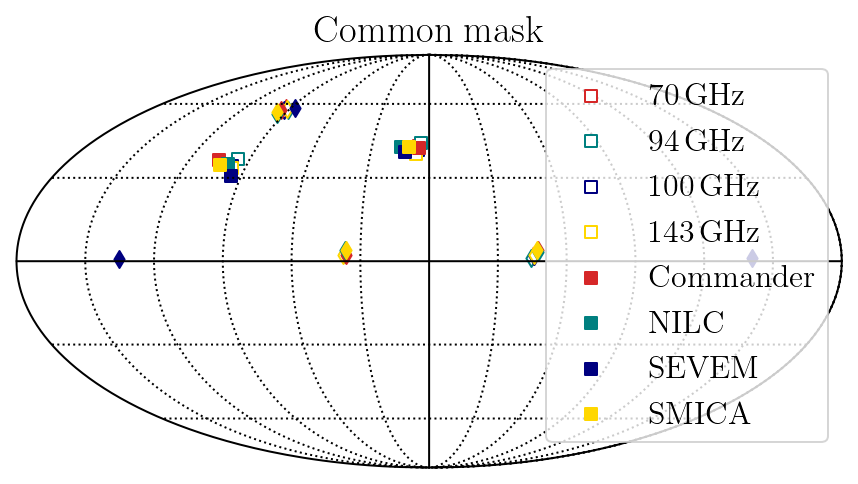

In [10]:
# Plot MVs on northern hemisphere
for m in range(Nmasks):
    hp.graticule()
    for n in range(Nmaps):
        for l in [2,3]:
            thetas = mvs_Planck[m][n][l].T[0]
            phis = mvs_Planck[m][n][l].T[1]
            if (l==2): label = labels_Planck[n];
            else: label=None
            if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors_Planck[n], label=label)
            else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors_Planck[n], label=label)
    plt.legend(loc='upper right')
    plt.title(labels_mask[m])
    plt.show()

In [11]:
# Compute oriented-area vectors Planck
ws_Planck = [[],[],[]]
for m in range(Nmasks):
    for n in range(Nmaps):
        ws_n = [0,0]
        for l in range(2,lmax+1):
            ws_l = []
            for i in range(len(mvs_Planck[m][n][l])-1):
                mv1 = polymv.otherfuncs.to_cart(mvs_Planck[m][n][l])[i]
                for j in range(i+1, len(mvs_Planck[m][n][l])):
                    mv2 = polymv.otherfuncs.to_cart(mvs_Planck[m][n][l])[j]
                    ws_l.append(np.cross(mv1, mv2))
            ws_n.append(ws_l)
        ws_Planck[m].append(ws_n)

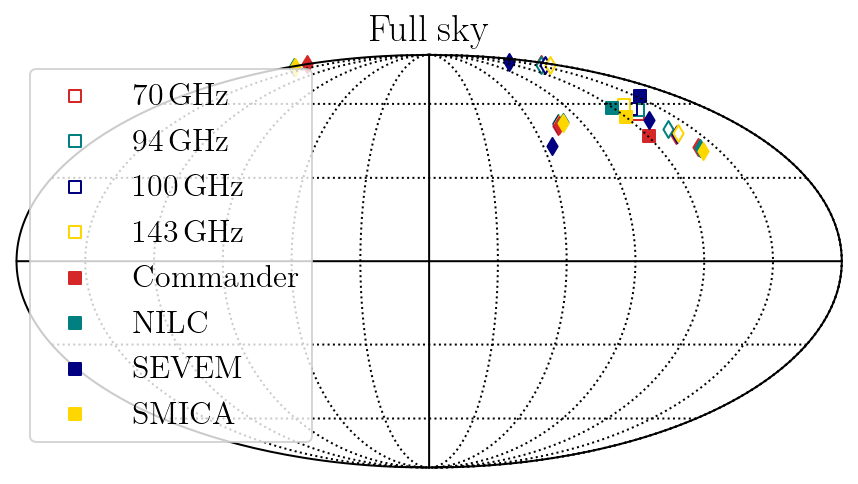

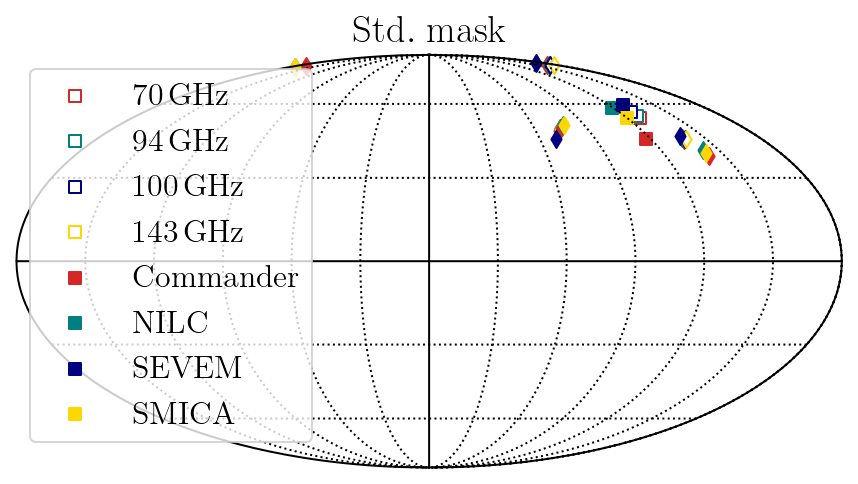

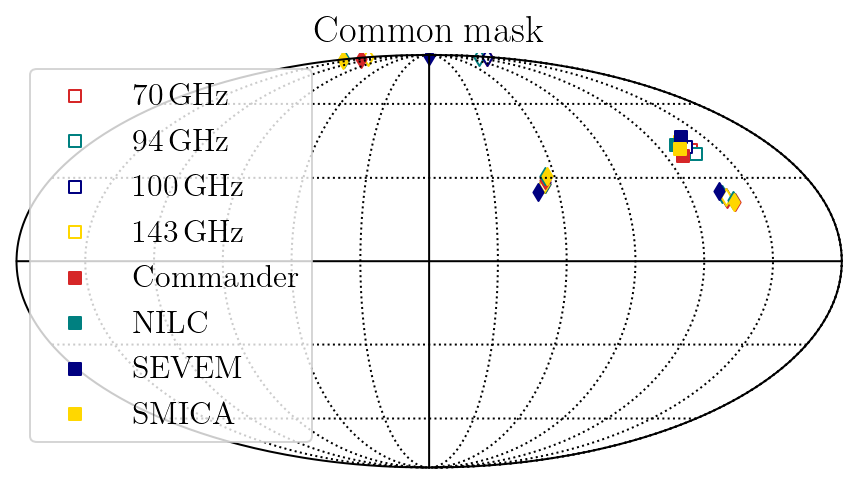

In [12]:
# Plot oriented areas from northern-sky MVs
for m in range(Nmasks):
    hp.graticule()
    for n in range(Nmaps): 
        for l in range(2, 4):
            thetas = np.zeros((len(ws_Planck[m][n][l])))
            phis = np.zeros((len(ws_Planck[m][n][l])))
            for i in range(len(ws_Planck[m][n][l])):
                thetas[i] = hp.vec2ang(ws_Planck[m][n][l][i])[0]
                phis[i] =  hp.vec2ang(ws_Planck[m][n][l][i])[1]
                if thetas[i] > np.pi/2:
                    thetas[i] = np.pi - thetas[i]
                    phis[i] = np.pi + phis[i]
            if (l==2): label = labels_Planck[n];
            else: label=None
            if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors_Planck[n], label=label)
            else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors_Planck[n], label=label)
    plt.legend()
    plt.title(labels_mask[m])
    plt.show()

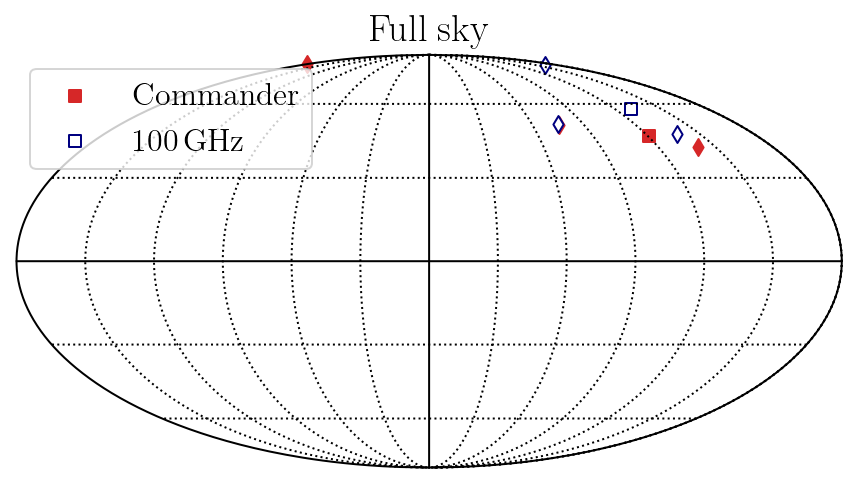

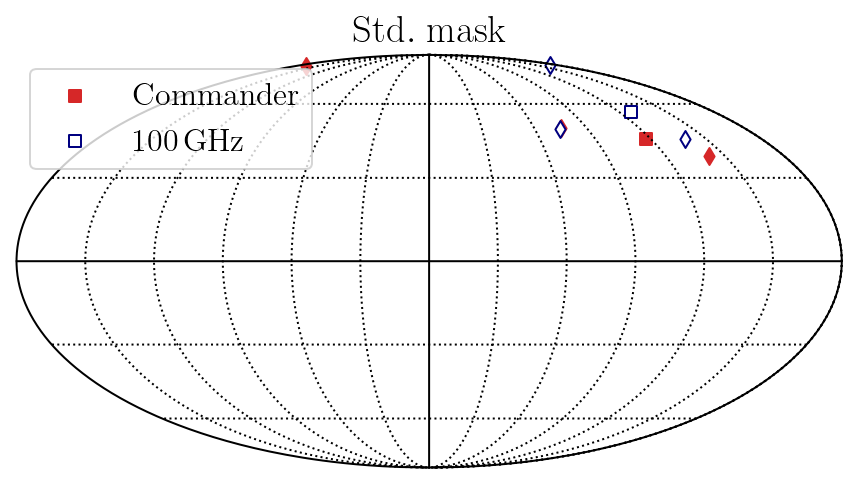

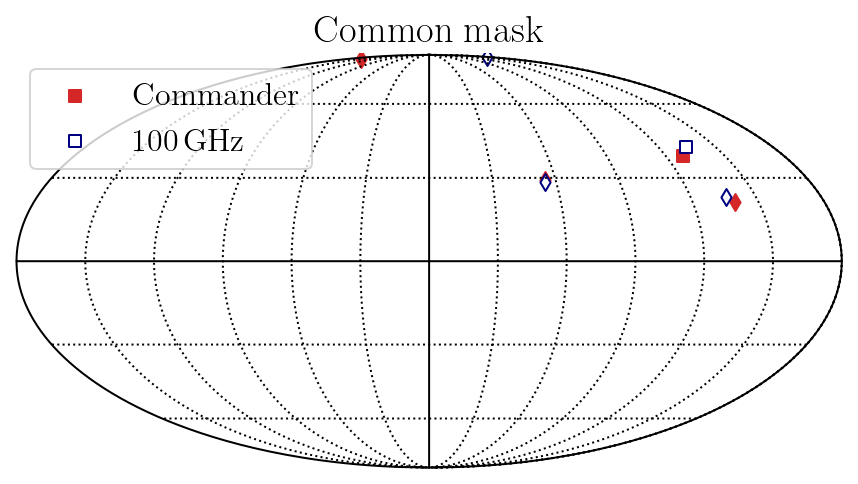

In [13]:
# Plot oriented areas from northern-sky MVs
for m in range(Nmasks):
    hp.graticule()
    for n in [index_Planck, index_Hayley]: 
        for l in range(2, 4):
            thetas = np.zeros((len(ws_Planck[m][n][l])))
            phis = np.zeros((len(ws_Planck[m][n][l])))
            for i in range(len(ws_Planck[m][n][l])):
                thetas[i] = hp.vec2ang(ws_Planck[m][n][l][i])[0]
                phis[i] =  hp.vec2ang(ws_Planck[m][n][l][i])[1]
                if thetas[i] > np.pi/2:
                    thetas[i] = np.pi - thetas[i]
                    phis[i] = np.pi + phis[i]
            if (l==2): label = labels_Planck[n];
            else: label=None
            if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors_Planck[n], label=label)
            else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors_Planck[n], label=label)
    plt.legend()
    plt.title(labels_mask[m])
    plt.show()

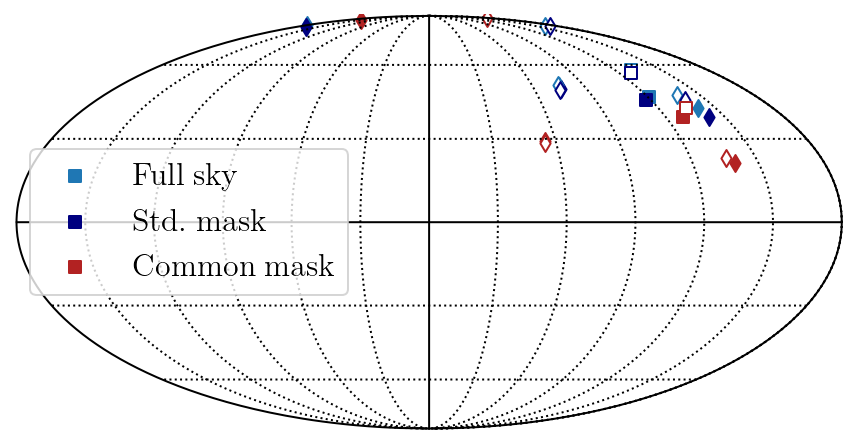

In [14]:
# Plot oriented areas from northern-sky MVs
hp.graticule()
for n in [index_Planck, index_Hayley]: 
    for m in range(Nmasks):
        for l in range(2, 4):
            thetas = np.zeros((len(ws_Planck[m][n][l])))
            phis = np.zeros((len(ws_Planck[m][n][l])))
            for i in range(len(ws_Planck[m][n][l])):
                thetas[i] = hp.vec2ang(ws_Planck[m][n][l][i])[0]
                phis[i] =  hp.vec2ang(ws_Planck[m][n][l][i])[1]
                if thetas[i] > np.pi/2:
                    thetas[i] = np.pi - thetas[i]
                    phis[i] = np.pi + phis[i]
            if (l==2): label = labels_mask[m];
            else: label=None
            if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors_mask[m], label=label)
            else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors_mask[m])
plt.legend()
plt.show()

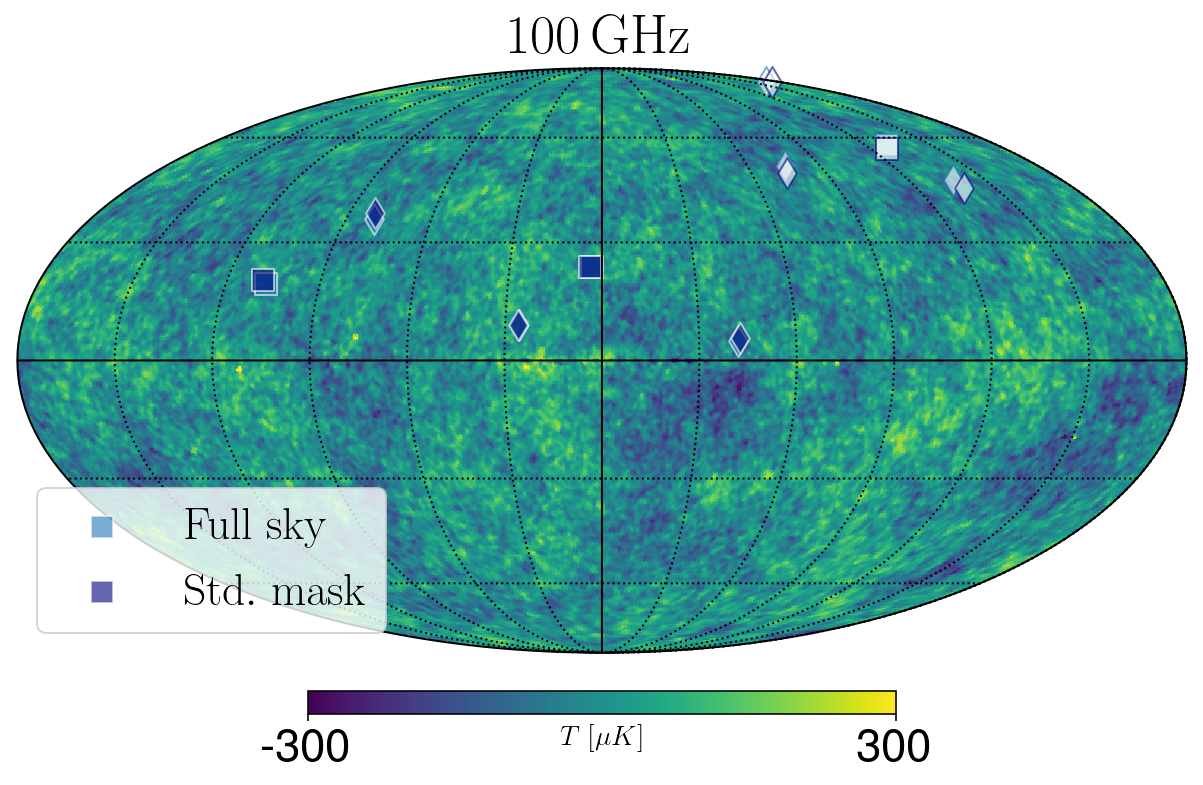

In [15]:
# Plot oriented areas from northern-sky MVs
plt.rc('font',**{'family':'Helvetica','size':23})
markersize = 120
hp.mollview(maps_Planck[index_Hayley], min=-300, max=300, unit=r"$T\ [\mu K]$")
hp.graticule()
plt.title(labels_Planck[index_Hayley])

  
for n in [index_Hayley]: 
    for m in [0, 1]:
        for l in [2,3]:
            thetas = mvs_Planck[m][n][l].T[0]
            phis = mvs_Planck[m][n][l].T[1]
            if (l==2): label = labels_mask[m];
            else: label=None
            hp.projscatter(thetas, phis, marker=markers[l], color=colors_mask[m], label=label, s=markersize, edgecolor="white", alpha=0.6)
            
        for l in [2,3]:
            thetas = np.zeros((len(ws_Planck[m][n][l])))
            phis = np.zeros((len(ws_Planck[m][n][l])))
            for i in range(len(ws_Planck[m][n][l])):
                thetas[i] = hp.vec2ang(ws_Planck[m][n][l][i])[0]
                phis[i] =  hp.vec2ang(ws_Planck[m][n][l][i])[1]
                if thetas[i] > np.pi/2:
                    thetas[i] = np.pi - thetas[i]
                    phis[i] = np.pi + phis[i]
            if (l==2): label = labels_mask[m];
            else: label=None
            if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors_mask[m], label=label)
            else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors_mask[m], s=markersize, alpha=0.6)
                


plt.legend(loc="lower left")
plt.savefig("map_quad-oct_alignment.pdf", format="PDF", bbox_inches='tight')
plt.show()

In [16]:
# Compute S_QO
SQO_Planck = np.array([[CMBanom.S_QO(ws_Planck[m][n]) for n in range(Nmaps)] for m in range(Nmasks)])

# Compute stats of data

In [17]:
print("Compute multipole vectors...")
mvs_Planck = [CMBanom.compute_MVs(maps_Planck, masks[m], lmax) for m in range(Nmasks)]
    
print("Compute oriented-area vectors...")
ws_Planck = [CMBanom.compute_Ws(mvs_Planck[m], lmax) for m in range(Nmasks)]

print("Compute SQO...")
SQO_Planck = np.array([[CMBanom.S_QO(ws_Planck[m][n]) for n in range(Nmaps)] for m in range(Nmasks)])

Compute multipole vectors...
Compute oriented-area vectors...
Compute SQO...


## Load or compute statistics of sims

In [18]:
if load_stats_from_cluster:
    SQO_sims = np.array([np.loadtxt(stats_dir+f"SQO_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
else:
    print("Load maps...")
    maps_sims = [hp.read_map(sims_dir+"map__"+str(n)+".fits")*1e3 for n in range(Nsims)]
    
    print("Compute multipole vectors...")
    mvs_sims = [CMBanom.compute_MVs(maps_sims, masks[m], lmax) for m in range(Nmasks)]
    
    print("Compute oriented-area vectors...")
    ws_sims = [CMBanom.compute_Ws(mvs_sims[m], lmax) for m in range(Nmasks)]

    print("Compute SQO...")
    SQO_sims = np.array([[CMBanom.S_QO(ws_sims[m][n]) for n in range(Nsims)] for m in range(Nmasks)])

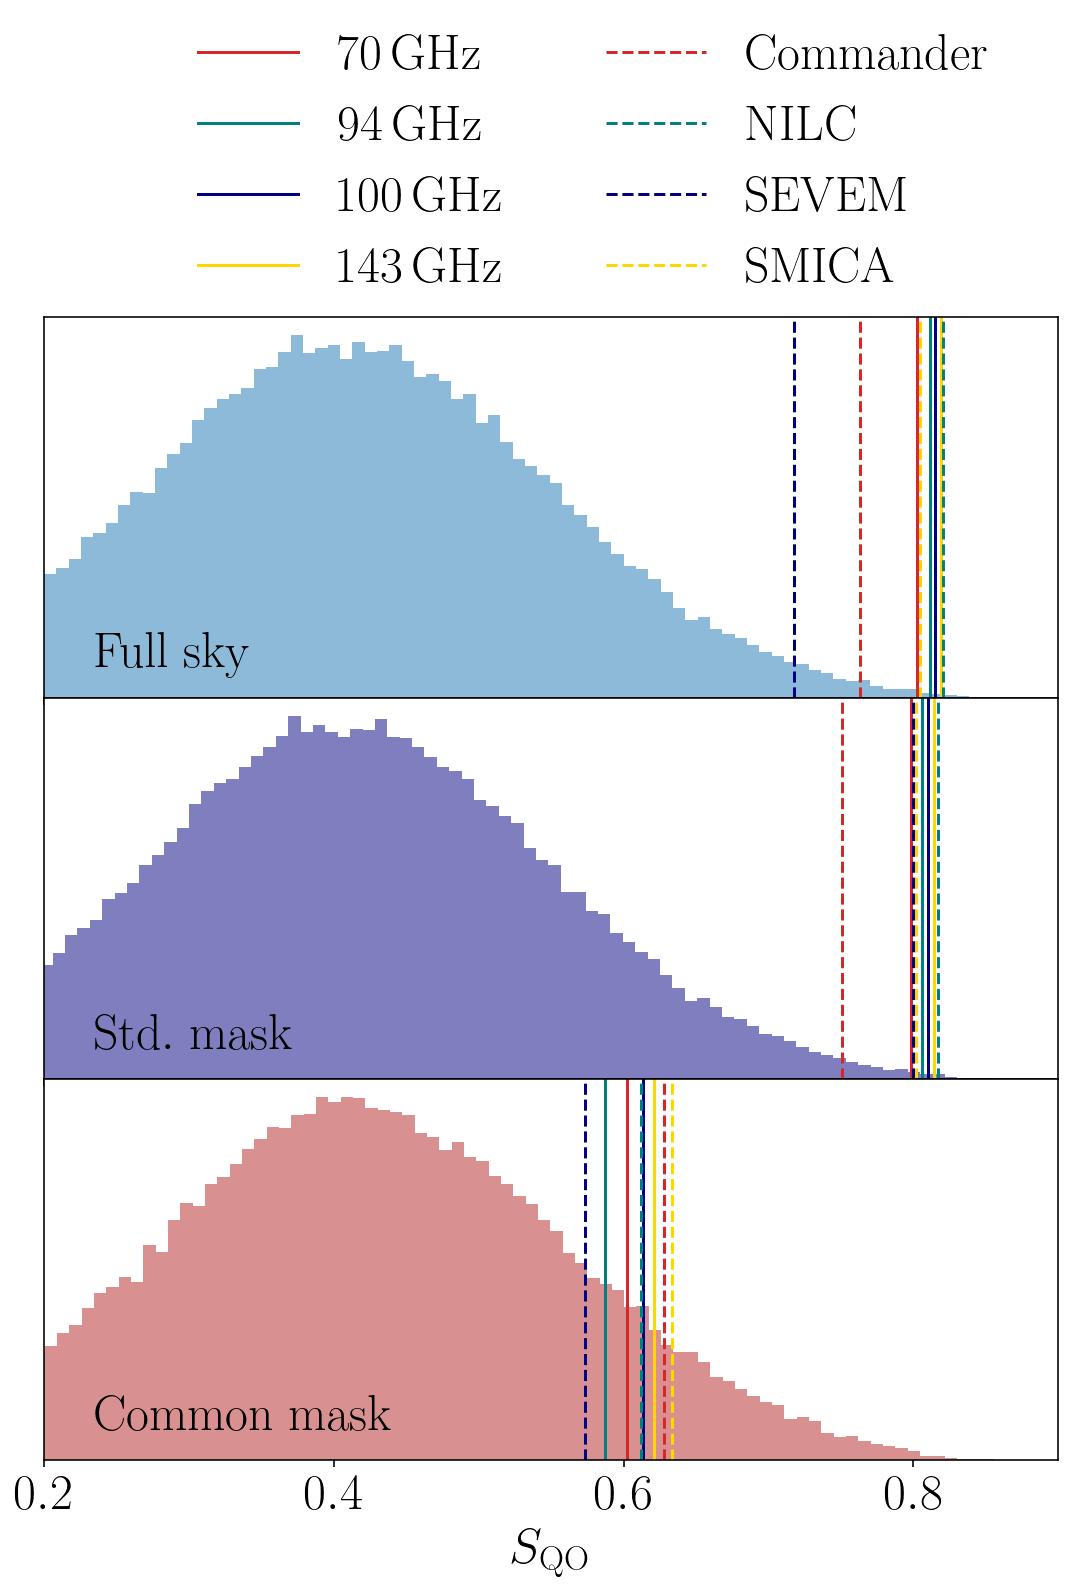

In [19]:
plt.rc('font',**{'family':'Helvetica','size':25})
fig, axs = plt.subplots(Nmasks, 1, figsize=(8, 10), sharex=True, gridspec_kw={'hspace': 0})

for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[m].axvline(SQO_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[m].hist(SQO_sims[m], bins=100, alpha=0.5, color=colors_mask[m])
    
    axs[m].set_xlim(0.2, 0.9)
    axs[m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[m].text(0.05, 0.05, labels_mask[m], horizontalalignment='left', verticalalignment='bottom', transform=axs[m].transAxes)

axs[-1].set_xlabel(r"$S_\mathrm{QO}$")
fig.legend(labels_Planck, loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.17), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

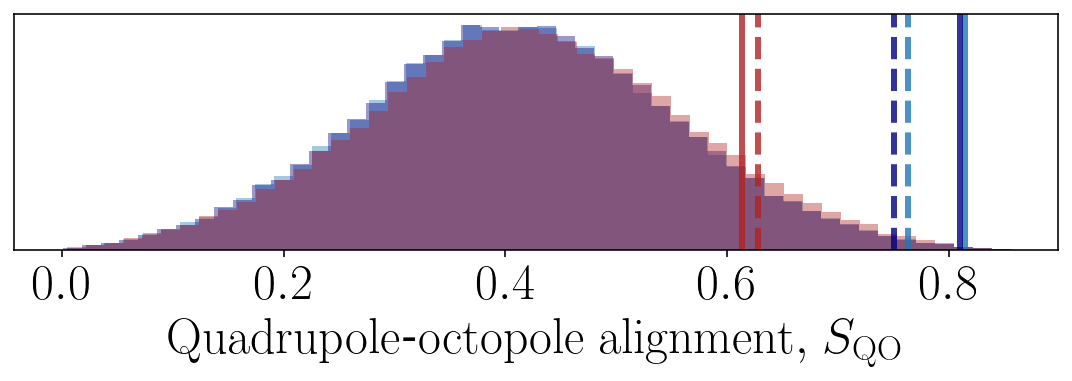

In [20]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 60)
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(SQO_sims[m], bins=50, color=colors_mask[m], alpha=0.4)
    plt.axvline(SQO_Planck[m][index_Hayley], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    plt.axvline(SQO_Planck[m][index_Planck], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
#plt.xlim(7e2, 2e5)
#plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$\mathrm{Quadrupole}$-$\mathrm{octopole\ alignment,}\ S_\mathrm{QO}$")
#plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Save stats to file

In [21]:
if save_stats: np.save(stats_dir+"SQO_real", SQO_Planck)

# Compute p-values

In [22]:
pvals = [[CMBanom.pval_higher(SQO_Planck[m][n], SQO_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)]

In [23]:
for m in range(Nmasks):
    print("-------------")
    print(names_mask[m])
    for n in range(Nmaps):
        print(f"S_QO = {SQO_Planck[m][n]:.3f}, p-value: {100*pvals[m][n]:.2f}% ({names_Planck[n]})")

-------------
fullsky
S_QO = 0.803, p-value: 0.11% (cleaned_70GHz_v9_nside_128)
S_QO = 0.811, p-value: 0.08% (cleaned_94GHz_v9_nside_128)
S_QO = 0.815, p-value: 0.06% (cleaned_100GHz_v9_nside_128)
S_QO = 0.819, p-value: 0.05% (cleaned_143GHz_v9_nside_128)
S_QO = 0.763, p-value: 0.46% (commander_nside_128)
S_QO = 0.820, p-value: 0.04% (nilc_nside_128)
S_QO = 0.717, p-value: 1.35% (sevem_nside_128)
S_QO = 0.805, p-value: 0.10% (smica_nside_128)
-------------
stdmask
S_QO = 0.798, p-value: 0.13% (cleaned_70GHz_v9_nside_128)
S_QO = 0.806, p-value: 0.10% (cleaned_94GHz_v9_nside_128)
S_QO = 0.810, p-value: 0.08% (cleaned_100GHz_v9_nside_128)
S_QO = 0.814, p-value: 0.06% (cleaned_143GHz_v9_nside_128)
S_QO = 0.751, p-value: 0.63% (commander_nside_128)
S_QO = 0.817, p-value: 0.06% (nilc_nside_128)
S_QO = 0.800, p-value: 0.13% (sevem_nside_128)
S_QO = 0.802, p-value: 0.11% (smica_nside_128)
-------------
commask
S_QO = 0.602, p-value: 10.18% (cleaned_70GHz_v9_nside_128)
S_QO = 0.587, p-value: 12

In [24]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*pvals[m][n]:.2f} ", end="")
    print("\\\\")

p-values
fullsky : &0.11 &0.08 &0.06 &0.05 &0.46 &0.04 &1.35 &0.10 \\
stdmask : &0.13 &0.10 &0.08 &0.06 &0.63 &0.06 &0.13 &0.11 \\
commask : &10.18 &12.26 &8.83 &7.98 &7.31 &9.00 &14.19 &6.81 \\


In [25]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{SQO_Planck[m][n]:.2f} ", end="")
    print("\\\\")

stats
fullsky : &0.80 &0.81 &0.81 &0.82 &0.76 &0.82 &0.72 &0.80 \\
stdmask : &0.80 &0.81 &0.81 &0.81 &0.75 &0.82 &0.80 &0.80 \\
commask : &0.60 &0.59 &0.61 &0.62 &0.63 &0.61 &0.57 &0.63 \\


## Is the common mask also producing MVs of sims pointing in the plane?
No, not for first 50 sims.

In [26]:
# Plot MVs on northern hemisphere
# 20: has quadrupole in the galactic plane
# 46: has 2 octopole MVs in plane for all mask choices
if load_stats_from_cluster==False:
    for m in range(Nmasks):
        hp.graticule()
        for n in range(46, 47):
            for l in [2,3]:
                thetas = mvs_sims[m][n][l].T[0]
                phis = mvs_sims[m][n][l].T[1]
                hp.projscatter(thetas, phis, marker=markers[l])
        plt.title(labels_mask[m])
        plt.show()
    hp.mollview(maps_sims[46])

In [27]:
# # Plot MVs on northern hemisphere
# n = 2
# for m in range(Nmasks):
#     hp.graticule()
#     for l in [2,3]:
#         thetas = mvs_Planck[m][n][l].T[0]
#         phis = mvs_Planck[m][n][l].T[1]
#         if (l==2): label = labels_Planck[n];
#         else: label=None
#         if n>3: hp.projscatter(thetas, phis, marker=markers[l], color=colors[n], label=label)
#         else: hp.projscatter(thetas, phis, marker=markers[l], color="white", edgecolor=colors[n], label=label)
#     plt.legend(loc='upper right')
#     plt.title(labels_mask[m])
#     plt.show()
# hp.mollview(maps_Planck[n])